Вихідний набір даних:
     місто місяць  температура  опалювальні_дні  витрати_на_опалення
0   Харків    Січ           -6               24                  4.1
1   Харків    Лют           -5               22                  4.0
2   Харків    Бер            1               16                  0.8
3   Харків    Кві           10                7                  1.6
4   Харків    Тра           17                1                  0.0
5   Харків    Чер           20                0                  0.0
6   Харків    Лип           22                0                  0.3
7   Харків    Сер           21                0                  0.4
8   Харків    Вер           15                2                  1.8
9   Харків    Жов            8               11                  1.7
10  Харків    Лис            1               16                  2.5
11  Харків    Гру           -4               22                  2.1


ЗАВДАННЯ 1. Діаграма розсіювання
----------------------------------------------

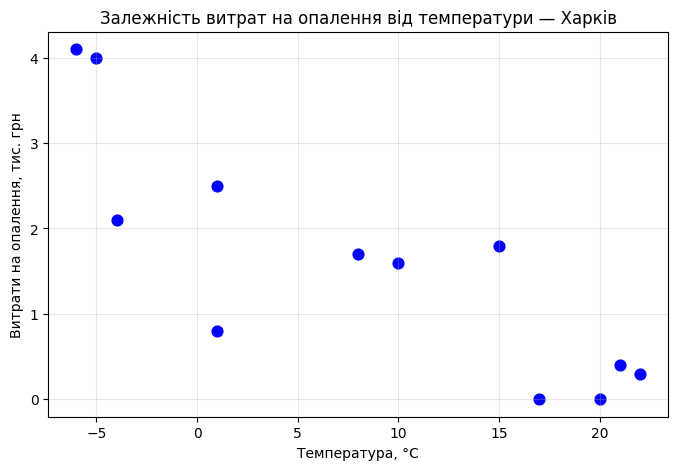

За діаграмою можна очікувати негативний зв'язок: зі зниженням температури витрати на опалення зазвичай зростають.


ЗАВДАННЯ 2. Коефіцієнти Пірсона і Спірмена
------------------------------------------------------------
Пірсон: r = -0.838, p-value = 0.0007
Спірмен: rho = -0.856, p-value = 0.0004

Пірсон: H0 відхиляємо. Кореляція статистично значуща.
Спірмен: H0 відхиляємо. Ранговий зв'язок статистично значущий.

95% ДІ для коефіцієнта Пірсона: (-0.953; -0.509)


ЗАВДАННЯ 3. Кореляційна матриця
------------------------------------------------------------
Кореляційна матриця Пірсона:
                     температура  опалювальні_дні  витрати_на_опалення
температура                1.000           -0.991               -0.838
опалювальні_дні           -0.991            1.000                0.833
витрати_на_опалення       -0.838            0.833                1.000

Кореляційна матриця Спірмена:
                     температура  опалювальні_дні  витрати_на_опалення
температура              

In [1]:
# ============================================================
# ПРАКТИКА 16
# Кореляційний аналіз
# Варіант 4 — Харків
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr


# ============================================================
# ПОБУДОВА ВИХІДНОГО НАБОРУ ДАНИХ
# ============================================================

np.random.seed(4)

city = "Харків"

monthly_temp = [
    -6, -5, 1, 10, 17, 20,
    22, 21, 15, 8, 1, -4
]

months = [
    "Січ", "Лют", "Бер", "Кві", "Тра", "Чер",
    "Лип", "Сер", "Вер", "Жов", "Лис", "Гру"
]

rows = []

for month, temp in zip(months, monthly_temp):

    heating_days = np.clip(
        18 - temp + np.random.normal(0, 1.5),
        0,
        30
    )

    heating_days = round(heating_days)

    cost = (
        0.15 * heating_days
        + np.random.normal(0, 1.0)
    )

    cost = round(max(cost, 0), 1)

    rows.append({
        "місто": city,
        "місяць": month,
        "температура": temp,
        "опалювальні_дні": heating_days,
        "витрати_на_опалення": cost
    })

climate = pd.DataFrame(rows)

print("Вихідний набір даних:")
print(climate)


# ============================================================
# ЗАВДАННЯ 1. Діаграма розсіювання
# ============================================================

print("\n")
print("ЗАВДАННЯ 1. Діаграма розсіювання")
print("-" * 60)

plt.figure(figsize=(8, 5))

plt.scatter(
    climate["температура"],
    climate["витрати_на_опалення"],
    color="blue",
    s=60
)

plt.xlabel("Температура, °C")
plt.ylabel("Витрати на опалення, тис. грн")
plt.title(
    "Залежність витрат на опалення від температури — Харків"
)

plt.grid(True, alpha=0.3)
plt.show()


print(
    "За діаграмою можна очікувати негативний зв'язок: "
    "зі зниженням температури витрати на опалення зазвичай зростають."
)


# ============================================================
# ЗАВДАННЯ 2. Коефіцієнти Пірсона і Спірмена
# ============================================================

print("\n")
print("ЗАВДАННЯ 2. Коефіцієнти Пірсона і Спірмена")
print("-" * 60)

x = climate["температура"]
y = climate["витрати_на_опалення"]

# Кореляція Пірсона
pearson_result = pearsonr(x, y)

print(
    f"Пірсон: r = {pearson_result.statistic:.3f}, "
    f"p-value = {pearson_result.pvalue:.4f}"
)

# Кореляція Спірмена
spearman_result = spearmanr(x, y)

print(
    f"Спірмен: rho = {spearman_result.statistic:.3f}, "
    f"p-value = {spearman_result.pvalue:.4f}"
)


# Перевірка статистичної значущості
alpha = 0.05

if pearson_result.pvalue < alpha:
    print(
        "\nПірсон: H0 відхиляємо. "
        "Кореляція статистично значуща."
    )
else:
    print(
        "\nПірсон: H0 не відхиляємо. "
        "Недостатньо підстав стверджувати, "
        "що кореляція відрізняється від нуля."
    )


if spearman_result.pvalue < alpha:
    print(
        "Спірмен: H0 відхиляємо. "
        "Ранговий зв'язок статистично значущий."
    )
else:
    print(
        "Спірмен: H0 не відхиляємо. "
        "Недостатньо підстав стверджувати, "
        "що ранговий зв'язок відрізняється від нуля."
    )


# 95% довірчий інтервал для коефіцієнта Пірсона
pearson_ci = pearson_result.confidence_interval(
    confidence_level=0.95
)

print(
    f"\n95% ДІ для коефіцієнта Пірсона: "
    f"({pearson_ci.low:.3f}; {pearson_ci.high:.3f})"
)


# ============================================================
# ЗАВДАННЯ 3. Кореляційна матриця трьох змінних
# ============================================================

print("\n")
print("ЗАВДАННЯ 3. Кореляційна матриця")
print("-" * 60)

corr_data = climate[
    [
        "температура",
        "опалювальні_дні",
        "витрати_на_опалення"
    ]
]

print("Кореляційна матриця Пірсона:")
print(corr_data.corr().round(3))


print("\nКореляційна матриця Спірмена:")
print(corr_data.corr(method="spearman").round(3))


# Пошук найсильнішої пари
corr_matrix = corr_data.corr()

pairs = []

columns = corr_matrix.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        pairs.append((
            columns[i],
            columns[j],
            abs(corr_matrix.iloc[i, j])
        ))

strongest_pair = max(pairs, key=lambda x: x[2])
weakest_pair = min(pairs, key=lambda x: x[2])

print(
    f"\nНайсильніша пара: "
    f"{strongest_pair[0]} — {strongest_pair[1]}, "
    f"|r| = {strongest_pair[2]:.3f}"
)

print(
    f"Найслабша пара: "
    f"{weakest_pair[0]} — {weakest_pair[1]}, "
    f"|r| = {weakest_pair[2]:.3f}"
)


# ============================================================
# ЗАВДАННЯ 4. Кореляція і причинність
# ============================================================

print("\n")
print("ЗАВДАННЯ 4. Кореляція і причинність")
print("-" * 60)

print(
    "У цьому наборі сильна кореляція між температурою "
    "і витратами на опалення не є випадковою: дані "
    "побудовані за формулою, у якій опалювальні дні "
    "безпосередньо залежать від температури."
)

print(
    "Спочатку heating_days обчислюються на основі "
    "18 - температура, а витрати на опалення залежать "
    "від кількості опалювальних днів."
)

print(
    "Тому в цьому штучно згенерованому наборі існує "
    "прямий зв'язок, закладений самою формулою генерації."
)

print(
    "Це відрізняється від прикладу з морозивом і утопленнями, "
    "де дві змінні можуть бути пов'язані через третій фактор. "
    "Тут основний зв'язок заданий безпосередньо способом "
    "побудови даних."
)


# ============================================================
# ЗАВДАННЯ 5. Перевірка впливу викиду
# ============================================================

print("\n")
print("ЗАВДАННЯ 5. Перевірка впливу викиду")
print("-" * 60)

# Створюємо копію початкового набору
climate_outlier = climate.copy()

# Додаємо аномальний рядок:
# надзвичайно великі витрати через аварію на котельні
outlier = pd.DataFrame({
    "місто": ["Харків"],
    "місяць": ["Аварія"],
    "температура": [10],
    "опалювальні_дні": [10],
    "витрати_на_опалення": [15.0]
})

climate_outlier = pd.concat(
    [climate_outlier, outlier],
    ignore_index=True
)

print("Набір із доданим аномальним спостереженням:")
print(climate_outlier)


# Нова кореляція Пірсона
pearson_outlier = pearsonr(
    climate_outlier["температура"],
    climate_outlier["витрати_на_опалення"]
)

# Нова кореляція Спірмена
spearman_outlier = spearmanr(
    climate_outlier["температура"],
    climate_outlier["витрати_на_опалення"]
)

print("\nБез викиду:")
print(
    f"Пірсон r = {pearson_result.statistic:.3f}"
)
print(
    f"Спірмен rho = {spearman_result.statistic:.3f}"
)

print("\nЗ викидом:")
print(
    f"Пірсон r = {pearson_outlier.statistic:.3f}"
)
print(
    f"Спірмен rho = {spearman_outlier.statistic:.3f}"
)

# Зміна коефіцієнтів
change_pearson = abs(
    pearson_outlier.statistic - pearson_result.statistic
)

change_spearman = abs(
    spearman_outlier.statistic - spearman_result.statistic
)

print(
    f"\nЗміна Пірсона: {change_pearson:.3f}"
)

print(
    f"Зміна Спірмена: {change_spearman:.3f}"
)

if change_pearson > change_spearman:
    print(
        "\nКоефіцієнт Пірсона змінився сильніше. "
        "Це узгоджується з його більшою чутливістю "
        "до викидів."
    )
else:
    print(
        "\nУ цьому конкретному наборі сильніше змінився "
        "коефіцієнт Спірмена."
    )


Контрольні питання
1. Чому коефіцієнт Пірсона ділиться на добуток стандартних відхилень?

Коефіцієнт Пірсона нормує коваріацію двох змінних на їхні стандартні відхилення. Завдяки цьому результат не залежить від одиниць вимірювання та завжди лежить у межах від −1 до 1. Значення, близьке до −1, означає сильний негативний лінійний зв'язок, а близьке до 1 — сильний позитивний.

2. Чому Спірмен використовує ранги?

Спірмен спочатку замінює фактичні значення їхніми рангами, а потім оцінює зв'язок між рангами. Через це окреме дуже велике або дуже мале значення має менший вплив на результат, ніж у Пірсона. Тому Спірмен є стійкішим до викидів і підходить для монотонних, але не обов'язково лінійних зв'язків.

3. Приклад, коли r ≈ 0, але зв'язок сильний.

Наприклад, якщо
Y
=
X
2
, а значення
X
 симетрично розподілені навколо нуля, лінійна кореляція Пірсона може бути близькою до нуля. Проте між X та Y існує чіткий нелінійний зв'язок: знаючи X, можна точно визначити Y.

4. Чому кореляція не доводить причинність?

Сильна кореляція показує статистичний зв'язок між змінними, але сама по собі не встановлює причинно-наслідковий механізм. У цій практиці зв'язок між температурою та витратами частково закладений безпосередньо у формулі генерації даних: heating_days залежить від температури, а cost — від heating_days. Тому для штучного набору причина зв'язку відома з конструкції моделі, але в реальних даних лише кореляції було б недостатньо для такого висновку.